## STOCHASTIC MODELING
MODULE 5 | LESSON 4


---





# **EM ALGORITHM AND REGIME SWITCHING MODELS**

|  |  |
|:---|:---|
|**Reading Time** |  60 minutes |
|**Prior Knowledge** |Linear Algebra, Maximum likelihood estimator, Monte Carlo  |
|**Keywords** | HMM, Markov chains, Transition Matrix


---

Let's put our newly-acquired knowledge of HMM to use. In this lesson we will develop a regime-switching model for the VIX index, a popular measure of overall stock market's expectation of volatility. The VIX index is developed by CBOE and constructed using implied volatility from S&P 500 index options. Thus, we can interpret it as a forward looking measure of market regime (i.e., calm vs. stressed periods), which can have wide applications for trading.

In [1]:
!pip install pandas_datareader


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Libraries needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web
from scipy.stats import norm
from scipy.optimize import minimize

## **1. Gathering and handling VIX Data**

Before jumping to the methodological implementation, let's gather our core data for VIX index prices during the last 10 years. We are going to gather this data daily from the FRED (Federal Reserve Economic Data):

In [3]:
vix_data = web.get_data_fred('VIXCLS', start='2015-01-01', end='2024-12-31')

This gets us the data on VIX levels, but for HMM we would likely rather **work with changes rather than levels**. This has a number of advantages:

- Changes are closer to stationary

- Mean-reverting around zero, which allows for better time comparison of regimes.

- Changes in VIX are more representative of actual trading gains if we want to eventually develop a trading strategy for VIX

Unfortunately, this can also mean that regime thresholds are less obvious and difficult to interpret.

In [4]:
vix_changes = vix_data.diff().dropna()

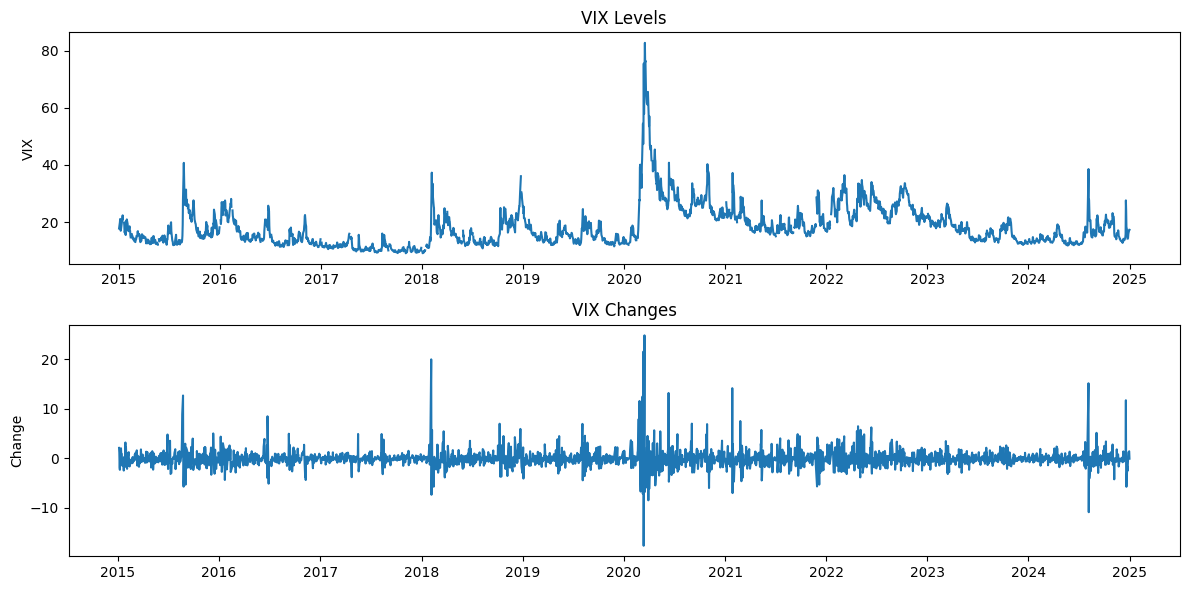

In [5]:
# Let's store the time series in a variable y for easier handling over the notebook
y = vix_changes.iloc[:,0].values

# Basic visualization
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(vix_data.index, vix_data.iloc[:,0])
plt.title('VIX Levels')
plt.ylabel('VIX')

plt.subplot(2, 1, 2)
plt.plot(vix_changes.index, vix_changes.iloc[:,0])
plt.title('VIX Changes')
plt.ylabel('Change')

plt.tight_layout()
plt.show()

## **2. Setting up the regime-switching HMM**

For the next step, we need to set up the HMM. This will require us to consider some initial parameter guesses (i.e., remember $\mu_1$, $\mu_2$, $\sigma_1$, $\sigma_2$, ...).

For illustrative purposes, we will set these initial parameter values based on the history of observed VIX changes. Notice, however, **that this is introducing look-ahead bias into the whole process**. This is because we are using information about the whole history of VIX that would not be known at each point in time. For example, say we consider a change of +/-10 in the VIX (such the one experienced in 2009) as the threshold for defining the regime as "stressed" period. This is information that we would never be able to know prior to that date and, thus, not 'fair game' for our trading strategy. Indeed, the perfectly correct solution would be to use a rolling window over the data to initialize these parameters based on the historical past distribution at each moment in time. For practicality, we are going to obviate this for now and focus on the rest of the implementation:

In [6]:
# Defined initial parameters based on data (see caveats)

# Regime 1 (Calm): small changes around zero
mu1 = 0.0  # Assume calm regime centered at zero

# Regime 2 (Stressed): large positive changes (high uncertainty)
stressed_threshold = np.percentile(y, 85)  # Top 15% of changes
mu2 = np.mean(y[y > stressed_threshold])

# Volatilities based on regime classification
calm_changes = y[np.abs(y) <= stressed_threshold]
stressed_changes = y[y > stressed_threshold]
sigma1 = np.std(calm_changes)
sigma2 = np.std(stressed_changes)

# Transition probabilities (default ad hoc assumptions)
p11 = 0.95  # Calm periods very persistent
p22 = 0.75  # Stressed periods less persistent

# Initial state probability
pi1 = 0.8   # Usually start in calm regime

# Combine into initial guess vector
initial_guess = [mu1, mu2, sigma1, sigma2, p11, p22, pi1]

## **3. Hamilton filter**

Now, under this setup, we can implement the Hamilton filter procedure we saw in previous lessons to identify the probabilities of each period leading to "calm" versus "stressed" period next. Let's do it!

*Note that in essence the following code is doing exactly the same of what we did in the previous example. However, we have modified some things slightly, including bounds to the parameters to preserve convergence*

In [7]:
EPS = 1e-12  # tiny floor to avoid underflow / log(0)


def emission_prob(y, mu, sigma):
    """Calculate emission probability: f(y_t | s_t = i)"""
    return norm.pdf(y, loc=mu, scale=sigma)


def hamilton_filter(y, mu, sigma, P, pi):
    T = len(y)
    n_states = len(mu)

    filtered_probs = np.zeros((T, n_states))
    predicted_probs = np.zeros((T, n_states))
    marginal_likelihoods = np.zeros(T)

    # Normalize just in case the initial pi isn't exactly on the simplex
    pi = np.asarray(pi, float)
    pi = pi / pi.sum()
    predicted_probs[0] = pi

    for t in range(T):
        # 1) Emissions (floored)
        emissions = np.array([emission_prob(y[t], mu[i], sigma[i]) for i in range(n_states)])
        emissions = np.maximum(emissions, EPS)

        # 2) Marginal likelihood (floored)
        ml = float(np.dot(predicted_probs[t], emissions))
        ml = max(ml, EPS)
        marginal_likelihoods[t] = ml

        # 3) Filter (Bayes) + renormalize defensively
        post = (predicted_probs[t] * emissions) / ml
        s = post.sum()
        filtered_probs[t] = post / s if s > 0 else np.full(n_states, 1.0/n_states)

        # 4) Predict next period
        if t < T - 1:
            pred = P.T @ filtered_probs[t]  # keep your convention
            pred = np.clip(pred, EPS, 1.0)
            predicted_probs[t + 1] = pred / pred.sum()

    log_likelihood = np.sum(np.log(marginal_likelihoods))
    return filtered_probs, predicted_probs, log_likelihood, marginal_likelihoods


def negative_log_likelihood(params, y):
    mu1, mu2, sigma1, sigma2, p11, p22, pi1 = params

    # Basic constraints
    if sigma1 <= 0 or sigma2 <= 0:
        return 1e10
    if not (0 <= p11 <= 1) or not (0 <= p22 <= 1):
        return 1e10
    if not (0 <= pi1 <= 1):
        return 1e10

    mu = np.array([mu1, mu2], float)
    sigma = np.array([sigma1, sigma2], float)
    P = np.array([[p11, 1 - p11],
                  [1 - p22, p22]], float)
    pi = np.array([pi1, 1 - pi1], float)

    try:
        _, _, log_likelihood, _ = hamilton_filter(y, mu, sigma, P, pi)
        if not np.isfinite(log_likelihood):
            return 1e10
        return -log_likelihood
    except Exception:
        return 1e10



def estimate_mle(y, initial_guess):
    bounds = [
        (None, None),      # mu1
        (None, None),      # mu2
        (1e-6, None),      # sigma1 > 0
        (1e-6, None),      # sigma2 > 0
        (1e-6, 1 - 1e-6),  # p11 in (0,1)
        (1e-6, 1 - 1e-6),  # p22 in (0,1)
        (1e-6, 1 - 1e-6),  # pi1 in (0,1)
    ]

    result = minimize(negative_log_likelihood, initial_guess,
                      args=(y,), method='L-BFGS-B', bounds=bounds)

    mu1, mu2, sigma1, sigma2, p11, p22, pi1 = result.x
    mu_est = np.array([mu1, mu2])
    sigma_est = np.array([sigma1, sigma2])
    P_est = np.array([[p11, 1 - p11], [1 - p22, p22]])
    pi_est = np.array([pi1, 1 - pi1])
    max_log_likelihood = -result.fun

    return mu_est, sigma_est, P_est, pi_est, max_log_likelihood


## **4. Estimation results**

Let's run our **Expectation-Maximization (EM) algorithm** to estimate these parameters (careful, this could take some time!):

In [8]:
initial_guess = [
    mu1,   # mu1
    mu2,   # mu2
    sigma1,   # sigma1  (low-vol regime)
    sigma2,   # sigma2  (high-vol regime)
    p11,   # p11     (persist in low-vol)
    p22,   # p22     (persist in high-vol)
    pi1    # pi1     (initial prob of state 1)
]

# 2) Estimate parameters via MLE
mu_est, sigma_est, P_est, pi_est, max_ll = estimate_mle(y, initial_guess)

print("Estimated parameters")
print("mu:", mu_est)
print("sigma:", sigma_est)
print("P:\n", P_est)
print("pi:", pi_est)
print("Max log-likelihood:", max_ll)

Estimated parameters
mu: [-0.09808769  0.24323624]
sigma: [0.83872071 3.60247454]
P:
 [[0.96257625 0.03742375]
 [0.12119156 0.87880844]]
pi: [1.00000e-06 9.99999e-01]
Max log-likelihood: -4186.376993551298


Now with these estimated parameters we can re-run the Hamilton filter to obtain, at each date $t$, the predicted probabilities of a regime ocurring next date ($t+1$). Specifically, using the Hamilton filter we will next compute:

1. **Filtered probabilities** ($Pr(s_t = i | y_{1:t})$): These are *posterior probabilities*, in the sense that they tell us how likely is that we are in state $s$ today given all data up to today.

2. **Predicted probabilities** ($Pr(s_t = i | y_{1:t-1})$): These are *prior probabilities*, as they use the transition matrix to inform us about the change of being in state $s$ today given what we know until yesterday.

In [9]:
filtered_probs, predicted_probs, loglike, _ = hamilton_filter(y, mu_est, sigma_est, P_est, pi_est)

We can use predicted probabilities to design trading strategies. For example, we will go long VIX if the predicted probabity of being at a high volatility state tomorrow (i.e., rises in VIX index) is very high. But we can also impose other rules like, conditional on being on a stressed state today (i.e, high VIX level), we can short VIX if the predicted probability of being in a calm state tomorrow is very high.

## **5. Trading strategy and backtest**

Let's leverage the use of predicted probabilities to design a trading strategy on the VIX. For now we will keep things simple and base our strategy on 2 simple rules:

1. Conditional on high chance of being in a calm state, **go long VIX** if the predicted probability of being in a stressed state tomorrow is higher than some threshold.

2. Conditional on high chance of being in a stressed state, **go short VIX** if the predicted probability of being in a calm state tomorrow is higher than some threshold.

\
In order to design such an strategy, we need to compute $Pr(s_{t+1} | y_{1:t})$, that is, the forecast for tomorrow's state of the world given information up to today. This is slightly different from the predicted probability we already have, but nothing we cannot compute. Mathematically, this simply entails propagating the distribution through transition matrix $P$:

\
$$
Pr(s_{t+1} | y_{1:t}) = P^T Pr(s_{t} = i | y_{1:t})
$$

In [10]:
next_probs = (P_est.T @ filtered_probs.T).T

Now let's create a convenient dataframe to then calculate the signals of our trading strategy:

In [11]:
# Use the same index dates as predictions
df = pd.DataFrame(index=vix_changes.index)

# Add VIX data in levels (rather than changes) and calculate returns for later on
df['VIX'] = vix_data.iloc[:,0]
df['VIX_ret'] = df['VIX'].pct_change()

# Include data on filtered probabilities
df['filt_s0'] = filtered_probs[:,0]
df['filt_s1'] = filtered_probs[:,1]

# Include data on predicted probabilities
df['prob_s0'] = next_probs[:,0]
df['prob_s1'] = next_probs[:,1]

# Shift by 1 the data on probs, in order to align todays's prediction of tomorrow's state with tomorrow's date
df['prob_s0'] = df['prob_s0'].shift(1)
df['prob_s1'] = df['prob_s1'].shift(1)

# Drop resulting missing values
df = df.dropna()

And our trading signal and positions vector. The trading rules are described above, but we may also need a vector indicating the position that we are holding at every date. In this case, we will hold a position until there is a change in the signal and assume we exit the position at the close price of that date. This is arguably very simplistic, but for now it will work well to illustrate things.

In [12]:
df["signal"] = 0

# Conditional on high probability of being at a calm regime, go long if high pred prob of stress
df.loc[(df['filt_s0'] > 0.5) & (df["prob_s1"] > 0.75), "signal"] = 1

# Conditional on high probability of being at a stressed regime, go short if high pred prob of calm
df.loc[(df['filt_s1'] > 0.5) & (df["prob_s0"] > 0.75), "signal"] = -1


df["position"] = (
    df["signal"]
      .replace(0, np.nan)   # treat 0 as "no new trade"
      .ffill()              # carry last non-zero forward
      .fillna(0)            # still 0 before first signal appears
      .astype(int))

If we further assume that the returns to holding cash are zero, we can simply calculate strategy returns as follows:

In [13]:
df['strat_rets'] = df['position']* df['VIX_ret']

It is also true that the VIX index that we are considering here is not exactly tradable, but there are many ETFs closely tracking it with minimal trading costs. Let's visualize how our very simple strategy performs versus a buy and hold on the VIX:

In [14]:
# Calculate cumulative returns
df["cum_vix"] = (1 + df["VIX_ret"]).cumprod()
df["cum_strat"] = (1 + df["strat_rets"]).cumprod()

In [ ]:
# Plot them!
plt.figure(figsize=(12,6))
plt.plot(df.index, df["cum_vix"], label="VIX Buy & Hold", color="black", alpha=0.7)
plt.plot(df.index, df["cum_strat"], label="HMM Strategy", color="blue", linewidth=2)
plt.title("Cumulative Returns: VIX vs HMM Strategy")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

Unfortunately, is seems that our strategy does not perform too well. You can go back and play around with the different thresholds for the signals, but it seems that this very simple approach is not enough. But this was kind of expected, wasn't it?  

## **4. Conclusion**

Well done! In this module we have implemented in practice a very simple regime change model for the VIX index and developed a trading strategy based on the model. Of course, the results where not very promising, as one would expect.

In the next module we will continue to explore applications of HMM for finance, hopefully with better results!

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
